Caso de estudio 1: ¿Cómo logra el éxito una empresa de bicicletas compartidas? Introducción

Se representa una empresa llamada Cyclistic, un sistema de bicicletas compartidas en Chicago.

La directora de marketing cree que el crecimiento futuro depende de conseguir más clientes con membresía anual.

Misión: ¿Cómo utilizan las bicicletas los usuarios ocasionales y los miembros de forma diferente?

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import pandas as pd

# Cargar el archivo
df = pd.read_csv('202507-divvy-tripdata.csv')

df = df.dropna()

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,41.932225,-87.658617,41.946176,-87.673308,member
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,41.822985,-87.607100,41.809855,-87.606755,member
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,41.926277,-87.630834,41.968812,-87.657659,member
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,41.949473,-87.646453,41.968812,-87.657659,member
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,41.926277,-87.630834,41.936253,-87.652662,member


In [5]:
df.describe()

,start_lat,start_lng,end_lat,end_lng
count,494293.000000,494293.000000,494293.000000,494293.000000
mean,41.902615,-87.644454,41.903203,-87.644750
std,0.041673,0.026287,0.041863,0.026445
min,41.648501,-87.841098,41.648501,-87.841098
25%,41.882134,-87.656868,41.882409,-87.656959
50%,41.895954,-87.639904,41.896617,-87.639968
75%,41.928712,-87.626804,41.928887,-87.627077
max,42.064854,-87.528232,42.064854,-87.528232


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 494293 entries, 0 to 763391
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             494293 non-null  object 
 1   rideable_type       494293 non-null  object 
 2   started_at          494293 non-null  object 
 3   ended_at            494293 non-null  object 
 4   start_station_name  494293 non-null  object 
 5   start_station_id    494293 non-null  object 
 6   end_station_name    494293 non-null  object 
 7   end_station_id      494293 non-null  object 
 8   start_lat           494293 non-null  float64
 9   start_lng           494293 non-null  float64
 10  end_lat             494293 non-null  float64
 11  end_lng             494293 non-null  float64
 12  member_casual       494293 non-null  object 
dtypes: float64(4), object(9)
memory usage: 52.8+ MB


In [7]:
# creamos una columna de duracion de trayecto
df["ride_length"] = (
    pd.to_datetime(df["ended_at"])
    - pd.to_datetime(df["started_at"])
).dt.total_seconds()/60

In [8]:
# Filtramos viajes con duraciones poco realistas (menos de 1 min o más de 24 horas)
df_clean = df[(df["ride_length"] >= 1) & (df["ride_length"] <= 1440)].copy()

In [9]:
# creamos una columna de dias de la semana
df_clean["day_of_week"] = pd.to_datetime(
    df["started_at"]
).dt.day_name()

In [10]:
# creamos una columna del mes

df_clean["month"] = pd.to_datetime(
    df["started_at"]
).dt.month_name()

In [11]:
# creamos una columna con la hora

df_clean["hour"] = pd.to_datetime(
    df["started_at"]
).dt.hour

In [12]:
# Duracion promedio

df_clean.groupby("member_casual")["ride_length"].mean()

member_casual
casual    24.358003
member    13.541340
Name: ride_length, dtype: float64

In [13]:
# Viaje por usuario

df_clean["member_casual"].value_counts()

member_casual
member    283130
casual    206467
Name: count, dtype: int64

In [14]:
# Cantidad de viajes por dia

df_clean.groupby(
    ["day_of_week","member_casual"]
).size()

day_of_week  member_casual
Friday       casual           29662
             member           33326
Monday       casual           21948
             member           39061
Saturday     casual           38346
             member           29958
Sunday       casual           31405
             member           29050
Thursday     casual           28816
             member           48593
Tuesday      casual           28833
             member           53261
Wednesday    casual           27457
             member           49881
dtype: int64

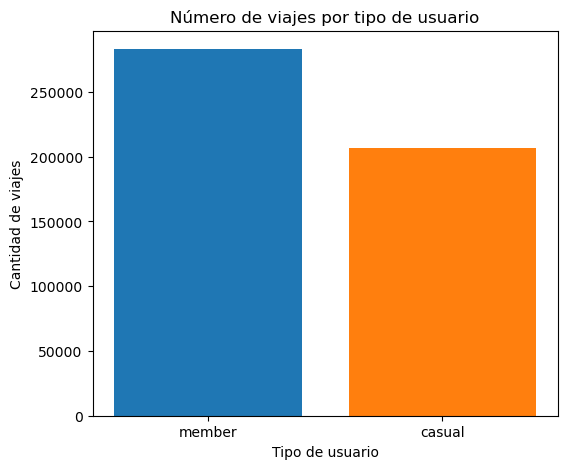

In [15]:
# Numero de viaje por tipo de usuario

# datos
type_member = df_clean["member_casual"].unique()
count_trip = df_clean["member_casual"].value_counts()

#crear grafico
fig, ax = plt.subplots(figsize=(6,5))

ax.bar(
    count_trip.index,
    count_trip.values,
    color=['#1f77b4', '#ff7f0e']
)
# agregamos titulos
ax.set_title("Número de viajes por tipo de usuario")
ax.set_xlabel("Tipo de usuario")
ax.set_ylabel("Cantidad de viajes")

plt.show()

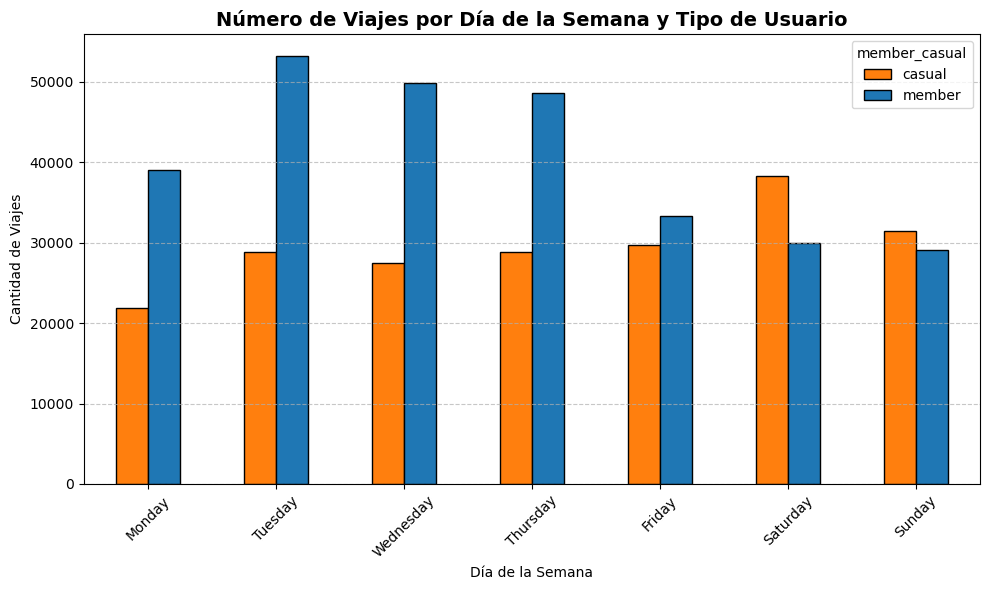

In [16]:
# Viaje por dia

# Definir el orden correcto de los días
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Agrupar y reindexar para ordenar los datos
viajes_por_dia = df_clean.groupby(["day_of_week", "member_casual"]).size().unstack().reindex(orden_dias)

# Graficar de forma agrupada usando pandas/matplotlib
viajes_por_dia.plot(kind="bar", figsize=(10, 6), color=['#ff7f0e', '#1f77b4'], edgecolor='black')
plt.title("Número de Viajes por Día de la Semana y Tipo de Usuario", fontsize=14, fontweight='bold')
plt.xlabel("Día de la Semana")
plt.ylabel("Cantidad de Viajes")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Análisis de comportamiento temporal:

Los Miembros anuales presentan picos de uso muy marcados de lunes a viernes en las horas de entrada y salida laboral (8:00 y 17:00), confirmando un uso enfocado en la conmutación diaria (commuting).

Los Usuarios ocasionales incrementan sustancialmente sus viajes durante los fines de semana y mantienen un volumen de uso constante y plano durante las horas centrales de la tarde, indicando un uso recreativo o turístico.

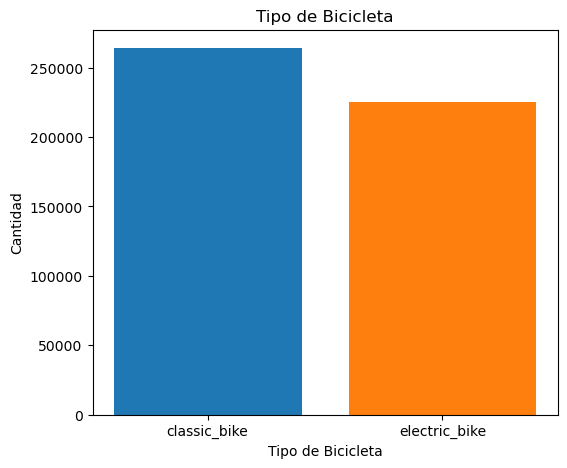

In [17]:
# tipo de Bicicleta

type_bike = df_clean["rideable_type"].unique()
count_bike = df_clean["rideable_type"].value_counts()

fig,ax = plt.subplots(figsize=(6,5))
ax.bar(
    count_bike.index,
    count_bike.values,
    color=['#1f77b4', '#ff7f0e','#2ca02c']
)
# agregamos titulos

ax.set_title ("Tipo de Bicicleta")
ax.set_xlabel ( "Tipo de Bicicleta")
ax.set_ylabel ("Cantidad")

plt.show()

Los usuarios ocasionales muestran una clara inclinación hacia las bicicletas eléctricas en comparación con las clásicas. Esto abre una oportunidad de conversión: promocionar los beneficios económicos de la membresía anual específicamente vinculados al ahorro en tarifas por minuto de las bicicletas eléctricas.

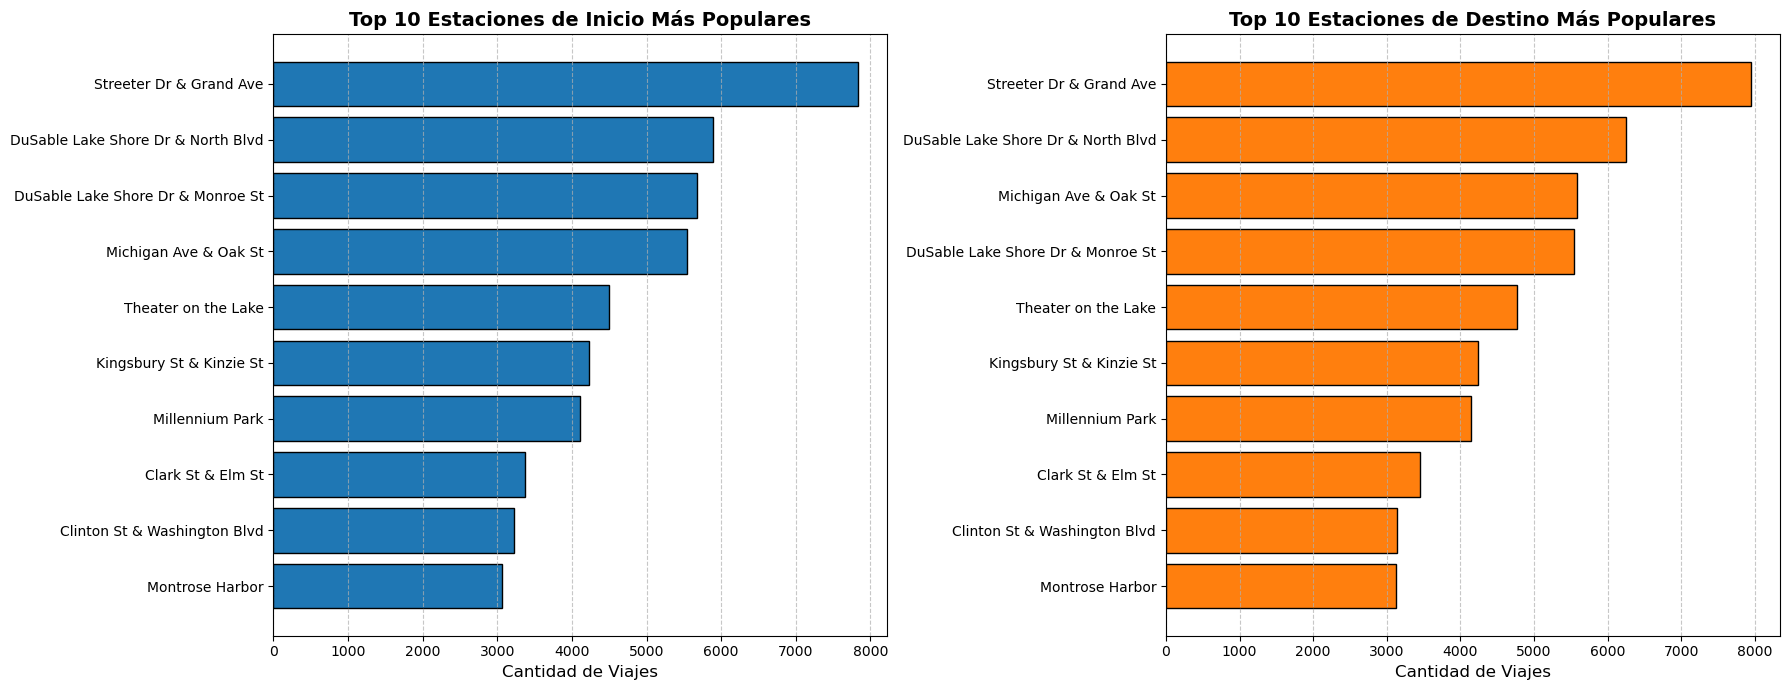

In [18]:
# Top de estaciones

#Datos
df_estaciones = df[['start_station_name', 'end_station_name']].dropna()

# Obtener el Top 10 de estaciones de inicio y fin
top_start = df_estaciones["start_station_name"].value_counts().head(10)
top_end = df_estaciones["end_station_name"].value_counts().head(10)

# Creamos una figura con 2 submétodos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# Gráfico 1: Top Estaciones de Inicio (Izquierda)
axes[0].barh(
    top_start.index,
    top_start.values,
    color='#1f77b4',
    edgecolor='black'
)
axes[0].set_title("Top 10 Estaciones de Inicio Más Populares", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Cantidad de Viajes", fontsize=12)
axes[0].invert_yaxis()  # Invierte el eje para que la más popular aparezca arriba del todo
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Gráfico 2: Top Estaciones de Fin (Derecha)
axes[1].barh(
    top_end.index,
    top_end.values,
    color='#ff7f0e',
    edgecolor='black'
)
axes[1].set_title("Top 10 Estaciones de Destino Más Populares", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Cantidad de Viajes", fontsize=12)
axes[1].invert_yaxis()  # Invierte el eje para mantener el orden de mayor a menor
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# Ajustamos el espacio entre los gráficos para que no se solapen los nombres
plt.tight_layout()
plt.show()

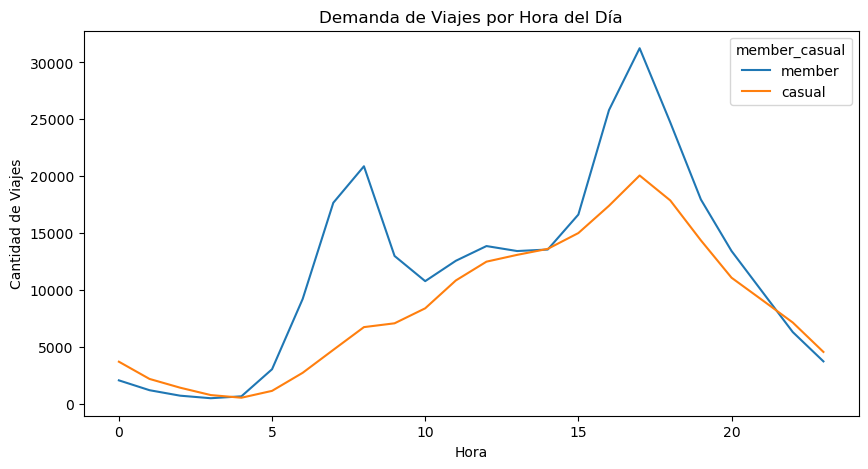

In [19]:
# Análisis por hora del día
# datos
hour=df_clean["hour"].unique()
ride_length=df_clean.groupby("hour")["ride_length"].mean()

# Gráfico de líneas para ver la demanda por hora
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_clean, x="hour", y="ride_length", hue="member_casual", estimator="size", errorbar=None)

plt.title("Demanda de Viajes por Hora del Día")
plt.xlabel("Hora")
plt.ylabel("Cantidad de Viajes")
plt.show()

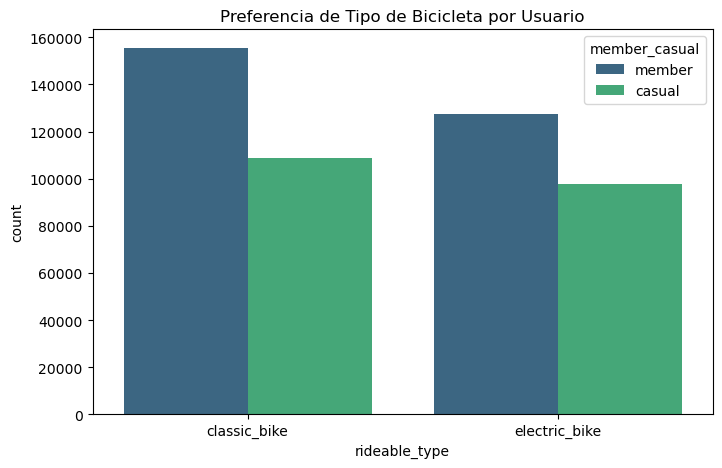

In [20]:
# preferencia de uso de bicicleta

# Gráfico de barras agrupadas usando seaborn
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="rideable_type", hue="member_casual", palette="viridis")
plt.title("Preferencia de Tipo de Bicicleta por Usuario")
plt.show()

Conclusiones y Recomendaciones Estratégicas

Campaña de Fines de Semana Enfocada en Ocasionales: Dado que los usuarios ocasionales dominan el uso los sábados y domingos con fines recreativos, se propone lanzar una "Membresía de Fin de Semana" o un descuento de conversión que se active directamente mediante notificaciones push al desbloquear una bicicleta en estos días.

Marketing de Guerrilla Geolocalizado: Utilizando el mapa del Top 10 de Estaciones, se deben colocar tótems publicitarios físicos y anuncios digitales geolocalizados (en Instagram/Google Ads) apuntando a las estaciones de inicio más populares de los usuarios ocasionales.

Estrategia "Bici Eléctrica Premium": Aprovechando que el usuario ocasional prefiere la bicicleta eléctrica, el marketing digital debe enfatizar que la membresía anual elimina el costo base de desbloqueo de estos modelos específicos, haciendo que sus viajes frecuentes sean drásticamente más económicos.